**Estudiantes:** Selena Castillo, Joaquin Moscol, Jefferson Sarango, Irvin Armijos, Matias
Romero

### **Tarea 1: Fundamentos de la Regresión Logística (Función Sigmoide)**

A diferencia de la regresión lineal, la regresión logística estima la probabilidad $P(Y = 1|X)$. Para garantizar que el resultado esté estrictamente acotado entre $[0, 1]$, se utiliza la función logística (Sigmoide):

1.
   $$P(Y = 1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}}$$

   Abra un nuevo Jupyter Notebook llamado `APE_015_Logistica.ipynb`.

2. Escenario: Predecir la Caída de un Servidor (1 = Sí, 0 = No) basándonos en la Temperatura de la CPU en °C ($X_1$).

Optimization terminated successfully.
         Current function value: 0.366379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Falla   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.4676
Time:                        17:48:38   Log-Likelihood:                -73.276
converged:                       True   LL-Null:                       -137.63
Covariance Type:            nonrobust   LLR p-value:                 7.874e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6766      1.372     -7.785      0.000     -13.365      -7.988
Temp_CPU       0.1604      0.

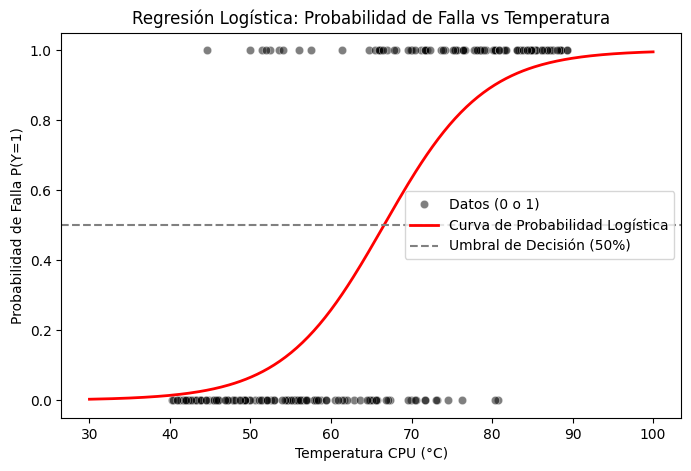

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados (Clasificación Binaria)
np.random.seed(42)
n_muestras = 200

# Variable predictora: Temperatura CPU (entre 40 y 90 grados)
temp_cpu = np.random.uniform(40, 90, size=n_muestras)

# Generar variable binaria probabilística (A mayor temperatura, mayor probabilidad de falla)

z = -10 + 0.15 * temp_cpu # Ecuación lineal (Log-Odds)
probabilidad_falla = 1 / (1 + np.exp(-z)) # Transformación Sigmoide

# Variable respuesta binaria (0 = OK, 1 = Falla) basada en la probabilidad
falla_servidor = np.random.binomial(1, p=probabilidad_falla)

df_sim = pd.DataFrame({'Temp_CPU': temp_cpu, 'Falla': falla_servidor})

# 2. Ajuste del Modelo Logístico (Logit)
X_log = sm.add_constant(df_sim['Temp_CPU'])
Y_log = df_sim['Falla']

# Entrenamiento usando MLE (Maximum Likelihood Estimation)
modelo_logit = sm.Logit(Y_log, X_log).fit()

print(modelo_logit.summary())

# 3. Visualización de la Curva Sigmoide
x_rango = np.linspace(30, 100, 300)
x_rango_sm = sm.add_constant(x_rango)
y_pred_prob = modelo_logit.predict(x_rango_sm)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temp_CPU', y='Falla', data=df_sim, color='black', alpha=0.5, label='Datos (0 o 1)')
plt.plot(x_rango, y_pred_prob, color='red', linewidth=2, label='Curva de Probabilidad Logística')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral de Decisión (50%)')
plt.title('Regresión Logística: Probabilidad de Falla vs Temperatura')
plt.xlabel('Temperatura CPU (°C)')
plt.ylabel('Probabilidad de Falla P(Y=1)')
plt.legend()
plt.show()

### Tarea 2: Hito del Proyecto - Predicción Dicotómica Regional (ABP)

1. Importe su dataset regional mediante pandas.
2. Ingeniería de Características: Seleccione una variable continua de interés y binarícela.

* **Ejemplo:** Si tiene "Ingresos", cree una nueva columna `Alta_Rentabilidad` donde $1$ si $\text{Ingresos} > \text{Promedio}$, y $0$ si $\text{Ingresos} \le \text{Promedio}$.

3. Seleccione al menos dos variables predictoras ($X_1, X_2$) para predecir esta nueva variable binaria.
4. Ajuste el modelo `sm.Logit()` e imprima el resumen.
5. Interprete los resultados: ¿Qué variable(s) incrementa(n) estadísticamente la probabilidad de que ocurra su evento (coeficiente positivo y valor-p < 0.05)?

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(42)
n_registros = 500

df = pd.DataFrame(
    {
        "Ingresos": np.random.normal(550, 180, n_registros).round(2),
        "Anios_Educacion": np.random.randint(6, 19, n_registros),  # X1
        "Horas_Trabajadas": np.random.normal(40, 8, n_registros).round(1),  # X2
        "Edad": np.random.randint(18, 65, n_registros),
    }
)

# Limpiar posibles valores negativos en la simulación
df["Ingresos"] = df["Ingresos"].apply(lambda x: max(x, 150.0))

print("--- Primeras filas del dataset ---")
print(df.head(), "\n")
promedio_ingresos = df["Ingresos"].mean()

# Creamos la variable binaria (1 si > Promedio, 0 si <= Promedio)
df["Alta_Rentabilidad"] = (df["Ingresos"] > promedio_ingresos).astype(int)

print(f"Promedio regional de ingresos calculado: ${promedio_ingresos:.2f}")
print("Distribución de la nueva clase binaria (0 = No, 1 = Sí):")
print(df["Alta_Rentabilidad"].value_counts(), "\n")

# Define the predictor variables
variables_predictoras = ['Anios_Educacion', 'Horas_Trabajadas']

X = df[variables_predictoras]
Y = df["Alta_Rentabilidad"]

# IMPORTANTE EN STATSMODELS: Agregar manualmente la constante (intercepto beta_0)
X = sm.add_constant(X)

modelo_logit = sm.Logit(Y, X).fit()

print("\n--- RESUMEN DEL MODELO DE REGRESIÓN LOGÍSTICA ---")
print(modelo_logit.summary())

--- Primeras filas del dataset ---
   Ingresos  Anios_Educacion  Horas_Trabajadas  Edad
0    639.41               15              41.2    61
1    525.11                7              38.2    20
2    666.58               16              46.6    39
3    824.15               13              39.0    23
4    507.85               16              46.0    19 

Promedio regional de ingresos calculado: $551.77
Distribución de la nueva clase binaria (0 = No, 1 = Sí):
Alta_Rentabilidad
1    252
0    248
Name: count, dtype: int64 

Optimization terminated successfully.
         Current function value: 0.688784
         Iterations 4

--- RESUMEN DEL MODELO DE REGRESIÓN LOGÍSTICA ---
                           Logit Regression Results                           
Dep. Variable:      Alta_Rentabilidad   No. Observations:                  500
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                            2
Date: 

### Tarea 3: Evaluación del Modelo (Matriz de Confusión)

Un modelo de clasificación no se evalúa con el $R^2$, sino contando cuántos aciertos y errores cometió.

1. Utilice scikit-learn para calcular las predicciones y generar la Matriz de Confusión del modelo simulado en la Tarea 1.

Dataset cargado: /content/enemdu_vivienda_hogar_2026_02.csv
Mediana del arriendo: 150.0
Registros válidos: 8757

Variables predictoras:


,Numero_cuartos,Numero_dormitorios,Area_rural
0,4,3,0
1,3,3,0
2,4,3,0
3,3,2,0
4,4,3,0



Variable respuesta:


,Arriendo_alto
0,0
1,0
2,1
3,0
4,0



--- EVALUACIÓN DEL MODELO REGIONAL ---
Exactitud: 75.04%
Precisión: 69.80%
Sensibilidad: 65.52%
F1-score: 0.6759

Reporte de clasificación:
                  precision    recall  f1-score   support

Arriendo no alto       0.78      0.81      0.80      1584
   Arriendo alto       0.70      0.66      0.68      1044

        accuracy                           0.75      2628
       macro avg       0.74      0.73      0.74      2628
    weighted avg       0.75      0.75      0.75      2628



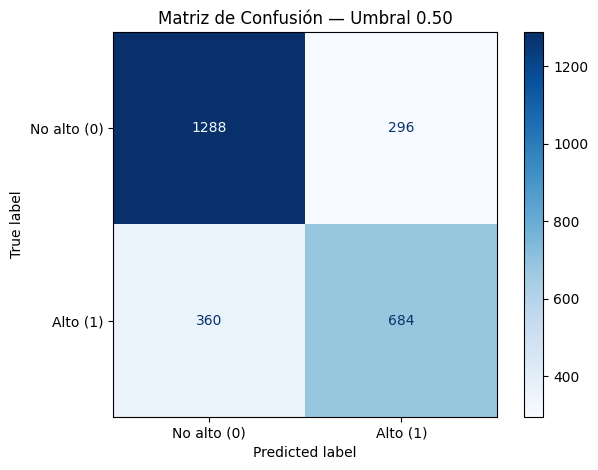

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

archivos = glob.glob("/content/enemdu_vivienda_hogar_2026_02*.csv")

if len(archivos) == 0:
    raise FileNotFoundError(
        "No se encontró el dataset. Suba el archivo "
        "enemdu_vivienda_hogar_2026_02.csv a Google Colab."
    )

df = pd.read_csv(
    archivos[0],
    sep=";",
    encoding="utf-8"
)

print("Dataset cargado:", archivos[0])

datos = df[["vi141", "vi06", "vi07", "area"]].copy()

for columna in ["vi141", "vi06", "vi07", "area"]:
    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

datos = datos.dropna()

datos = datos[
    (datos["vi141"] > 0)
    & (datos["vi141"] < 999999)
    & (datos["vi06"] > 0)
    & (datos["vi07"] >= 0)
    & (datos["area"].isin([1, 2]))
].copy()

datos = datos.rename(
    columns={
        "vi141": "Valor_arriendo",
        "vi06": "Numero_cuartos",
        "vi07": "Numero_dormitorios"
    }
)

datos["Area_rural"] = (
    datos["area"] == 2
).astype(int)

mediana_arriendo = datos["Valor_arriendo"].median()

datos["Arriendo_alto"] = (
    datos["Valor_arriendo"] > mediana_arriendo
).astype(int)

print("Mediana del arriendo:", mediana_arriendo)
print("Registros válidos:", len(datos))

X_regional = datos[
    [
        "Numero_cuartos",
        "Numero_dormitorios",
        "Area_rural"
    ]
]

Y_regional = datos["Arriendo_alto"]

print("\nVariables predictoras:")
display(X_regional.head())

print("\nVariable respuesta:")
display(Y_regional.head())

X_train, X_test, y_train, y_test = train_test_split(
    X_regional,
    Y_regional,
    test_size=0.30,
    random_state=42,
    stratify=Y_regional
)

modelo_regional = LogisticRegression(
    max_iter=2000
)

modelo_regional.fit(
    X_train,
    y_train
)

probabilidades = modelo_regional.predict_proba(
    X_test
)[:, 1]

predicciones_clase = (
    probabilidades >= 0.50
).astype(int)

cm = confusion_matrix(
    y_test,
    predicciones_clase
)

exactitud = accuracy_score(
    y_test,
    predicciones_clase
)

precision = precision_score(
    y_test,
    predicciones_clase,
    zero_division=0
)

sensibilidad = recall_score(
    y_test,
    predicciones_clase,
    zero_division=0
)

f1 = f1_score(
    y_test,
    predicciones_clase,
    zero_division=0
)

print("\n--- EVALUACIÓN DEL MODELO REGIONAL ---")
print(f"Exactitud: {exactitud * 100:.2f}%")
print(f"Precisión: {precision * 100:.2f}%")
print(f"Sensibilidad: {sensibilidad * 100:.2f}%")
print(f"F1-score: {f1:.4f}")

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        predicciones_clase,
        target_names=[
            "Arriendo no alto",
            "Arriendo alto"
        ],
        zero_division=0
    )
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No alto (0)",
        "Alto (1)"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusión — Umbral 0.50")
plt.tight_layout()
plt.show()

### Tarea 4: ABI - El Análisis del Umbral (Thresholding) y Falsos Positivos

Por defecto, Python asume que si $P(Y = 1) \ge 0.50$, la clasificación es 1. Sin embargo, en ingeniería, el costo de un "Falso Negativo" (predecir que el servidor no fallará y que termine explotando) suele ser mucho mayor que un "Falso Positivo" (ir a revisar un servidor que estaba bien).

1. Investigue cómo alterar el umbral modifica la Matriz de Confusión.
2. Cree un bloque de código que recalcule y muestre la matriz de confusión (o simplemente los valores de Falsos Positivos y Falsos Negativos) utilizando un umbral estricto conservador del 0.20 (es decir, clasificar como 'Falla' si la probabilidad es apenas $\ge 20\%$).
3. Redacte un análisis de qué le sucedió a los Falsos Positivos frente a los Falsos Negativos, y decida qué umbral (0.50 o 0.20) recomendaría para las políticas públicas o de ingeniería en su proyecto regional.


🔹 UMBRAL = 0.5
TN: 95 | FP: 15
FN: 17 | TP: 73
Accuracy: 0.84
Precision: 0.83
Recall: 0.81

🔹 UMBRAL = 0.2
TN: 75 | FP: 35
FN: 9 | TP: 81
Accuracy: 0.78
Precision: 0.70
Recall: 0.90


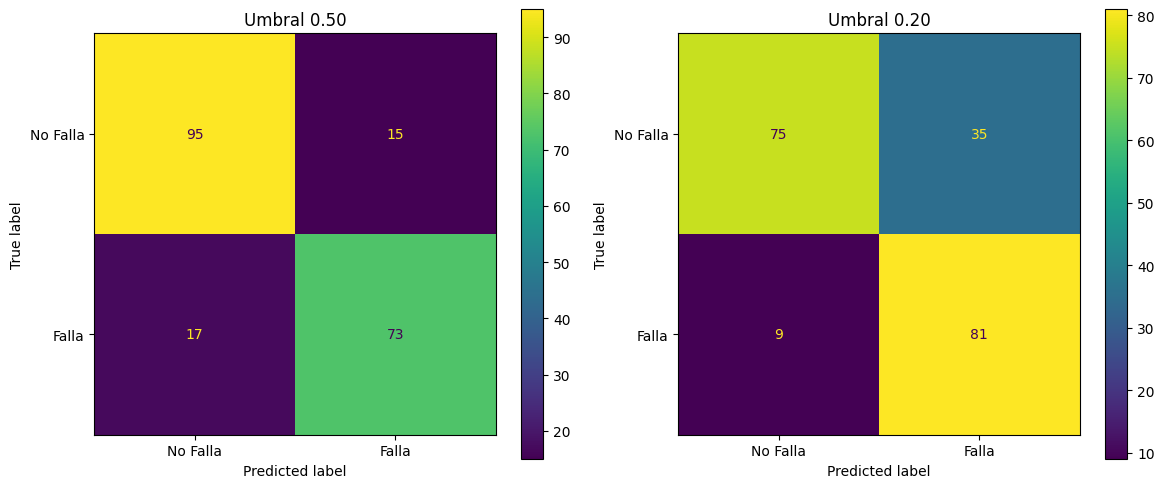

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

# Probabilidades
probabilidades = modelo_logit.predict(X_log)

# Función para evaluar
def evaluar_umbral(y_true, probs, umbral):
    pred = (probs >= umbral).astype(int)
    cm = confusion_matrix(y_true, pred)

    tn, fp, fn, tp = cm.ravel()

    print(f"\n🔹 UMBRAL = {umbral}")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")

    print(f"Accuracy: {accuracy_score(y_true, pred):.2f}")
    print(f"Precision: {precision_score(y_true, pred):.2f}")
    print(f"Recall: {recall_score(y_true, pred):.2f}")

    return cm

# Evaluar ambos umbrales
cm_50 = evaluar_umbral(Y_log, probabilidades, 0.50)
cm_20 = evaluar_umbral(Y_log, probabilidades, 0.20)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_50, display_labels=["No Falla", "Falla"])
disp1.plot(ax=ax[0])
ax[0].set_title("Umbral 0.50")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_20, display_labels=["No Falla", "Falla"])
disp2.plot(ax=ax[1])
ax[1].set_title("Umbral 0.20")

plt.tight_layout()
plt.show()

## 3. Análisis de Falsos Positivos vs Falsos Negativos y elección del umbral

Al comparar los resultados obtenidos con los umbrales de **0.50** y **0.20**, se observa un cambio importante en el comportamiento del modelo. Con el umbral de 0.50, el modelo es más conservador, lo que reduce los **Falsos Positivos (FP)**, pero incrementa los **Falsos Negativos (FN)**, es decir, algunos eventos reales no son detectados.

Por otro lado, al utilizar un umbral de **0.20**, el modelo clasifica más casos como positivos. Esto provoca un aumento en los **Falsos Positivos**, ya que se generan más alertas innecesarias, pero al mismo tiempo se reducen los **Falsos Negativos**, lo que significa que el modelo detecta mejor los eventos importantes.

Este comportamiento refleja un equilibrio entre dos tipos de error:

* Minimizar **Falsos Negativos** implica no dejar pasar eventos críticos.
* Minimizar **Falsos Positivos** implica evitar falsas alarmas.

En el contexto de un proyecto regional o de ingeniería, donde el costo de no detectar un evento puede ser alto (por ejemplo, fallas en sistemas, riesgos ambientales o problemas operativos), es preferible reducir los Falsos Negativos. Por esta razón, se recomienda el uso de un **umbral de 0.20**, ya que permite una detección más temprana de posibles eventos, aunque implique un mayor número de falsas alarmas.

En conclusión, el umbral de 0.20 es más adecuado cuando se prioriza la seguridad y la prevención, mientras que el umbral de 0.50 sería más conveniente en escenarios donde se busca mayor precisión y menor cantidad de alertas innecesarias.

# Preguntas de Control - Análisis Probabilístico Avanzado

---

### ¿Cuál es la esencia matemática de transformar una probabilidad en Log-Odds, y por qué este cambio de dominio es fundamental para el entendimiento de la causalidad probabilística?

La esencia matemática reside en mapear un dominio acotado a uno infinito. La probabilidad $p$ existe en el intervalo cerrado $[0, 1]$. Al calcular la razón de probabilidades u *Odds* $\frac{p}{1-p}$, se elimina el límite superior, extendiendo el rango a $[0, \infty)$. Finalmente, al aplicar la función logit mediante el logaritmo natural:

$$\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$$

Se transforma el rango al dominio continuo de los números reales $(-\infty, +\infty)$. Este cambio de dominio es fundamental porque permite utilizar un modelo lineal ($\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k$) para estimar la relación entre las variables de entrada y el evento, garantizando que al aplicar la función logística inversa la probabilidad siempre permanezca dentro de $[0, 1]$. Además, permite interpretar cuantitativamente la causalidad: un incremento unitario en una variable $X_i$ produce un cambio aditivo constante $\beta_i$ en los Log-Odds, lo que equivale a multiplicar la razón de probabilidades por un factor $e^{\beta_i}$ (Odds Ratio).

---

### ¿Por qué la naturaleza del fenómeno (binario) nos obliga a abandonar la medida clásica de bondad de ajuste ($R^2$) y adoptar el Pseudo $R^2$ de McFadden, y qué nos dice este cambio sobre la relación entre la realidad y la medición?

Nos obliga a abandonarla porque el $R^2$ clásico asume una variable dependiente continua con errores normalmente distribuidos y varianza constante (homocedasticidad). En fenómenos binarios ($Y \in \{0, 1\}$), los residuos son inherentemente heterocedásticos y no normales. Además, los modelos logísticos se estiman por Máxima Verosimilitud (MLE) y no por Mínimos Cuadrados Ordinarios (OLS). El Pseudo $R^2$ de McFadden se define mediante la comparación de log-verosimilitudes:

$$R^2_{\text{McFadden}} = 1 - \frac{LL_{\text{modelo}}}{LL_{\text{nulo}}}$$

Donde $LL_{\text{modelo}}$ es la log-verosimilitud del modelo ajustado y $LL_{\text{nulo}}$ es la del modelo sin predictores. Este cambio revela que, cuando la realidad observada es dicotómica, medir el ajuste no consiste en evaluar qué tan cerca cae un dato de una recta continua, sino en cuantificar cuánta más certidumbre aporta el modelo en comparación con el azar, cambiando el paradigma de distancia de errores a ganancia de verosimilitud.

---

### Ante un caso de incertidumbre total (predicción 0.5), ¿de qué manera la estructura del modelo intenta forzar una decisión binaria, y qué riesgos enfrentamos al ignorar la zona gris de la probabilidad?

La estructura intenta forzar la decisión mediante la aplicación de un umbral o *cutoff* rígido (habitualmente $t = 0.5$), el cual asigna la categoría $1$ si $P(Y=1) \ge 0.5$ y $0$ en caso contrario. Ante una probabilidad de $0.5$, el modelo se encuentra en su estado de máxima entropía e incertidumbre, pero la regla de decisión colapsa arbitrariamente este estado continuo en una etiqueta binaria. Ignorar esta zona gris genera el riesgo de crear una falsa certeza hacia los toma de decisiones y elimina la gestión del riesgo operacional en entornos críticos, tratando casos límite con la misma validez que certezas probabilísticas absolutas.

---

### ¿Cuál es el conflicto esencial entre la sensibilidad y la especificidad, y cómo la elección de un umbral refleja los valores éticos y técnicos subyacentes en una decisión de ingeniería?

El conflicto esencial es un intercambio antagónico (*trade-off*): la Sensibilidad mide la proporción de verdaderos positivos detectados y la Especificidad la proporción de verdaderos negativos. Reducir el umbral de decisión para capturar más casos positivos incrementa la sensibilidad, pero inevitablemente aumenta los falsos positivos y disminuye la especificidad; elevar el umbral produce el efecto contrario. La elección del umbral refleja las prioridades técnicas y éticas del diseño: priorizar la sensibilidad es una decisión adecuada cuando el costo de un Falso Negativo es catastrófico (por ejemplo, omitir una falla en una estructura o un diagnóstico grave), aceptando el costo de inspecciones innecesarias; priorizar la especificidad se justifica cuando un Falso Positivo genera un daño severo, indebido o un costo prohibitivo.

---

### ¿Cuál es el propósito final de predecir probabilidades en lugar de estados binarios rígidos, y cómo esta distinción transforma nuestra capacidad de intervenir en la realidad?

El propósito final es conservar la gradación del riesgo y la incertidumbre intrínseca del fenómeno, evitando colapsar la información de forma prematura en una clasificación determinista. Esta distinción transforma la capacidad de intervención al permitir priorizar recursos eficientemente atendiendo primero los casos de mayor riesgo probabilístico, evaluar decisiones mediante el análisis de Valor Esperado combinando probabilidades con matrices de costo-beneficio, y adaptar los umbrales de acción a las políticas cambiantes de la organización sin necesidad de reentrenar el modelo.